## Employment-Trend Analysis

By Ken Burchfiel

Released under the MIT License

This notebook is used to analyze the data prepared within employment_data_prep.ipynb. Currently, it focuses on software-developer employment trends.

In [1]:
# import gc
# gc.collect()

In [2]:
import time
start_time = time.time()
from datetime import datetime
import pandas as pd
pd.set_option('display.max_columns', 1000)
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import svy # prerequisite: pip install svy within your Python environment
# The svy library allows us to analyze complex survey
# data. See https://svylab.com/docs/svy/.
import polars as pl
import gc
import os
from survey_analysis_functions import perform_svy_analysis, \
create_svy_reg, survey_pivot, save_and_display_image
from IPython.display import Image, display

Configuration variables:

Employment totals by occupation, year, and age range:

## Importing data files created within employment_data_prep.ipynb:

Note: Polars is **much** faster at importing large CSV files than is Pandas. However, since I'm more familiar with the Pandas library, I'll immediately convert the imported data to a Pandas DataFrame for easier analysis.

In [3]:
df = pl.read_csv('/home/kjb3/D1V1/kjb3largefiles/large_programming/\
datasets/cps/cps_employment_trends_revised.csv',
schema_overrides = {'year_as_str':pl.String}).to_pandas()
# This dataset was named df_condensed within employment_data_prep.ipynb.

df_full_emp_totals = pl.read_csv('Datasets/full_emp_totals.csv',
schema_overrides = {'period_val':pl.String, 'year_as_str':pl.String}).to_pandas()
df_ue_props = pl.read_csv('Datasets/full_ue_props.csv', 
schema_overrides = {'period_val':pl.String, 'year_as_str':pl.String}).to_pandas()

Checking and visualizing software-developer employment totals for different periods:

Employment totals by year:

In [4]:
df_full_emp_totals.query(
"(period == 'year_as_str') & (age_range == 'All') & (occ2010 == 'Software \
developers, applications and systems software') & period_val >= '2021'")

,period_val,occ2010,Total_emp_total,se_emp_total,lci_emp_total,uci_emp_total,cv_emp_total,df_emp_total,error_upper_emp_total,error_lower_emp_total,Response_Count_emp_total,period,age_range
305740,2021,"Software developers, applications and systems ...",2.009621e+06,50671.848476,1.910249e+06,2.108992e+06,0.025215,2134,99371.359063,99371.359063,6819,year_as_str,All
306715,2022,"Software developers, applications and systems ...",2.168218e+06,54320.893968,2.061692e+06,2.274744e+06,0.025053,2182,106526.085698,106526.085698,7049,year_as_str,All
307690,2023,"Software developers, applications and systems ...",2.213711e+06,55214.539093,2.105433e+06,2.321989e+06,0.024942,2197,108278.159764,108278.159764,6993,year_as_str,All
308664,2024,"Software developers, applications and systems ...",2.158349e+06,54503.650823,2.051462e+06,2.265236e+06,0.025252,2086,106887.211442,106887.211442,6857,year_as_str,All
309639,2025,"Software developers, applications and systems ...",2.331220e+06,60146.873831,2.213263e+06,2.449176e+06,0.025801,2016,117956.524420,117956.524420,6142,year_as_str,All
310614,2026,"Software developers, applications and systems ...",2.579029e+06,76969.750347,2.428055e+06,2.730004e+06,0.029844,1570,150974.328120,150974.328120,4612,year_as_str,All


Employment totals by age range for 2022 and 2026:

In [5]:
df_emp_by_year_and_age_range = df_full_emp_totals.query(
"(period == 'year_as_str') & (age_range != 'All') & (occ2010 == 'Software \
developers, applications and systems software') & period_val in ['2022', '2026']")[['age_range', 'period_val', 'Total_emp_total', 
'lci_emp_total', 'uci_emp_total']].sort_values(['age_range', 'period_val'])
# Creating a field that will make it easier to asses statistically-significant increases from 2022 to 2026:
# (Note: Certain increases may still be statistically significant even
# if their confidence intervals overlap--though I'll need to look further
# into how to identify such cases.)
df_emp_by_year_and_age_range['current_row_lci_minus_prev_row_uci'] = np.where((df_emp_by_year_and_age_range['period_val'] == '2026'), 
df_emp_by_year_and_age_range['lci_emp_total'] - df_emp_by_year_and_age_range['uci_emp_total'].shift(1), 
np.nan)
# Creating a similar field that will let us identify statistically-significant
# decreases:
df_emp_by_year_and_age_range['current_row_uci_minus_prev_row_lci'] = np.where((df_emp_by_year_and_age_range['period_val'] == '2026'), 
df_emp_by_year_and_age_range['uci_emp_total'] - df_emp_by_year_and_age_range['lci_emp_total'].shift(1), 
np.nan)

df_emp_by_year_and_age_range

,age_range,period_val,Total_emp_total,lci_emp_total,uci_emp_total,current_row_lci_minus_prev_row_uci,current_row_uci_minus_prev_row_lci
306706,22-24,2022,122476.637158,96556.803499,148396.470818,NaN,NaN
310605,22-24,2026,124107.532463,90098.089681,158116.975244,-58298.381137,61560.171745
306707,25-29,2022,368748.998183,323047.597716,414450.398651,NaN,NaN
310606,25-29,2026,423271.072287,357619.630317,488922.514258,-56830.768334,165874.916542
306708,30-34,2022,391456.440600,346912.501945,436000.379255,NaN,NaN
310607,30-34,2026,505338.922400,436958.965189,573718.879611,958.585934,226806.377666
306709,35-39,2022,330760.176142,291319.546013,370200.806271,NaN,NaN
310608,35-39,2026,416155.111325,358322.768618,473987.454032,-11878.037653,182667.908020
306710,40-44,2022,249364.217617,215292.490054,283435.945179,NaN,NaN
310609,40-44,2026,348438.501725,294729.494981,402147.508469,11293.549801,186855.018415


In [6]:
## Specifying certain chart arguments:

chart_width = 600
chart_height = 500
chart_scale = 4

annotation_text = "Source: Current Population Survey data from IPUMS.<br>\
2026 data includes January through August only.<br>By Ken \
Burchfiel. Released under the CC-BY license.<br>\
GitHub project: https://github.com/kburchfiel/employment_trends"

error_bar_text = '<i>Error bars represent 95% confidence intervals</i>'

### Graphing software-developer employment by year (with and without error bars):

Error-bar variables: error_upper_emp_total error_lower_emp_total
Charts/software_developer_employment_by_year_with_error_bars


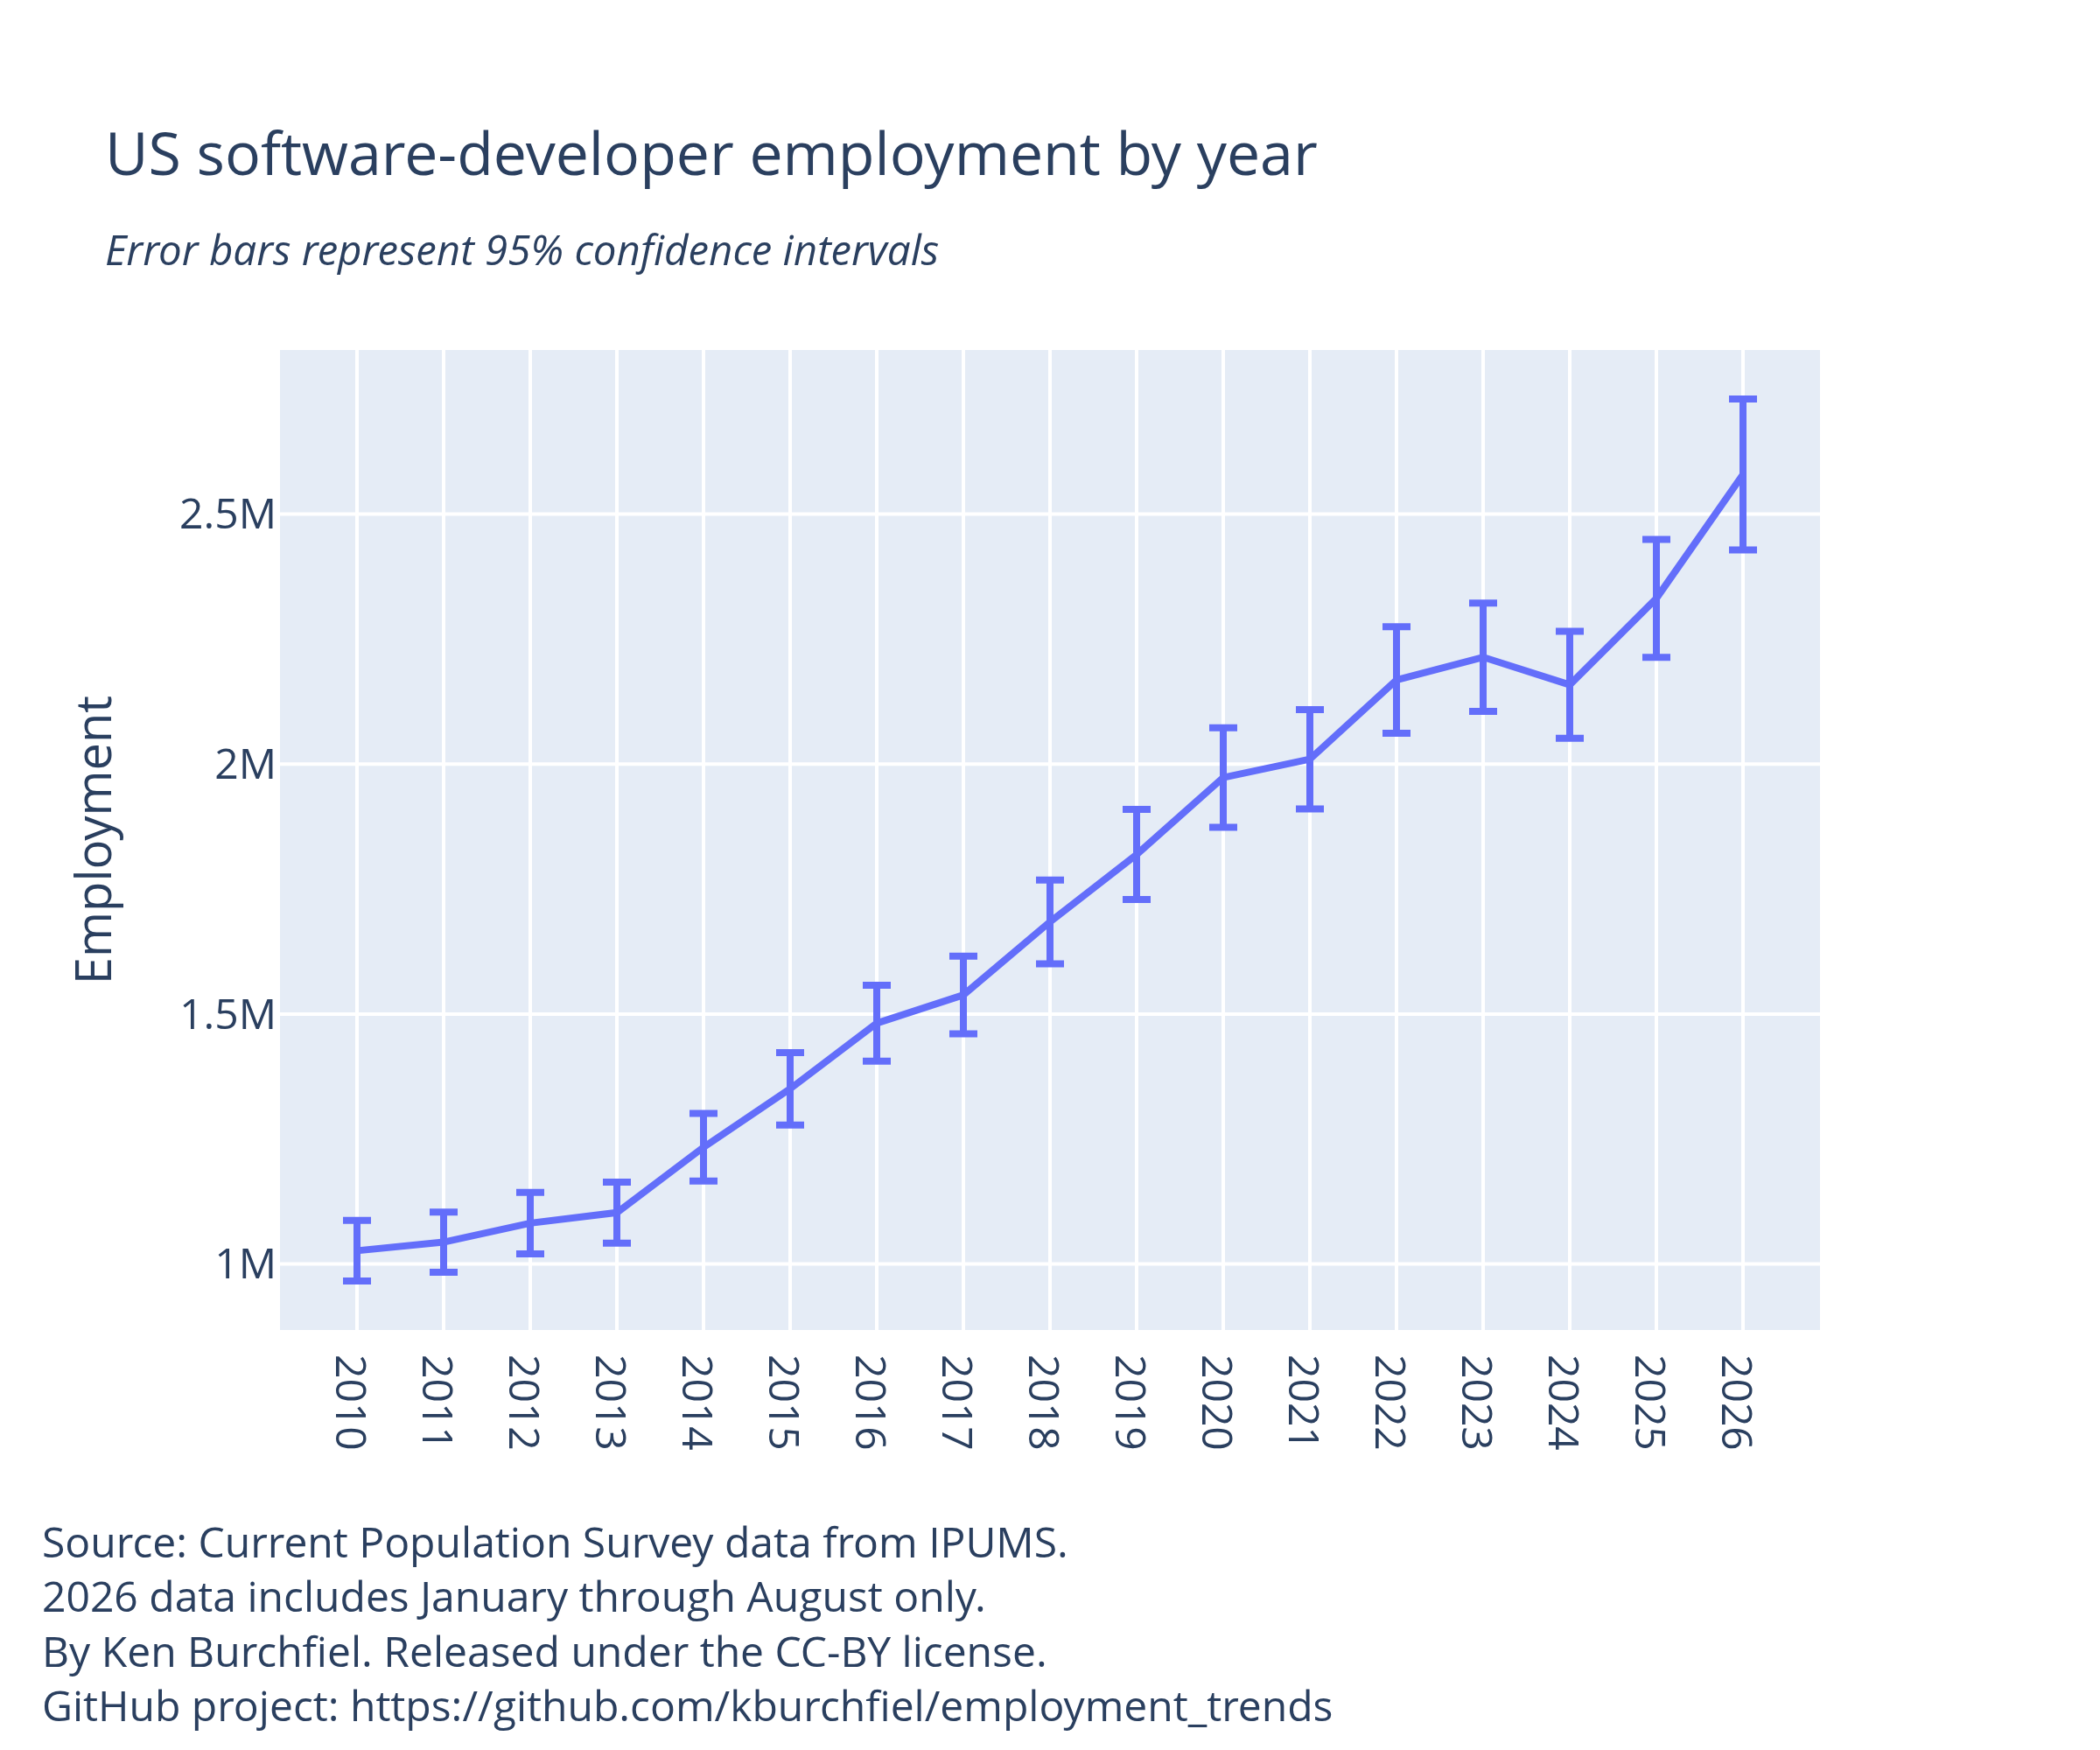

Error-bar variables: None None
Charts/software_developer_employment_by_year


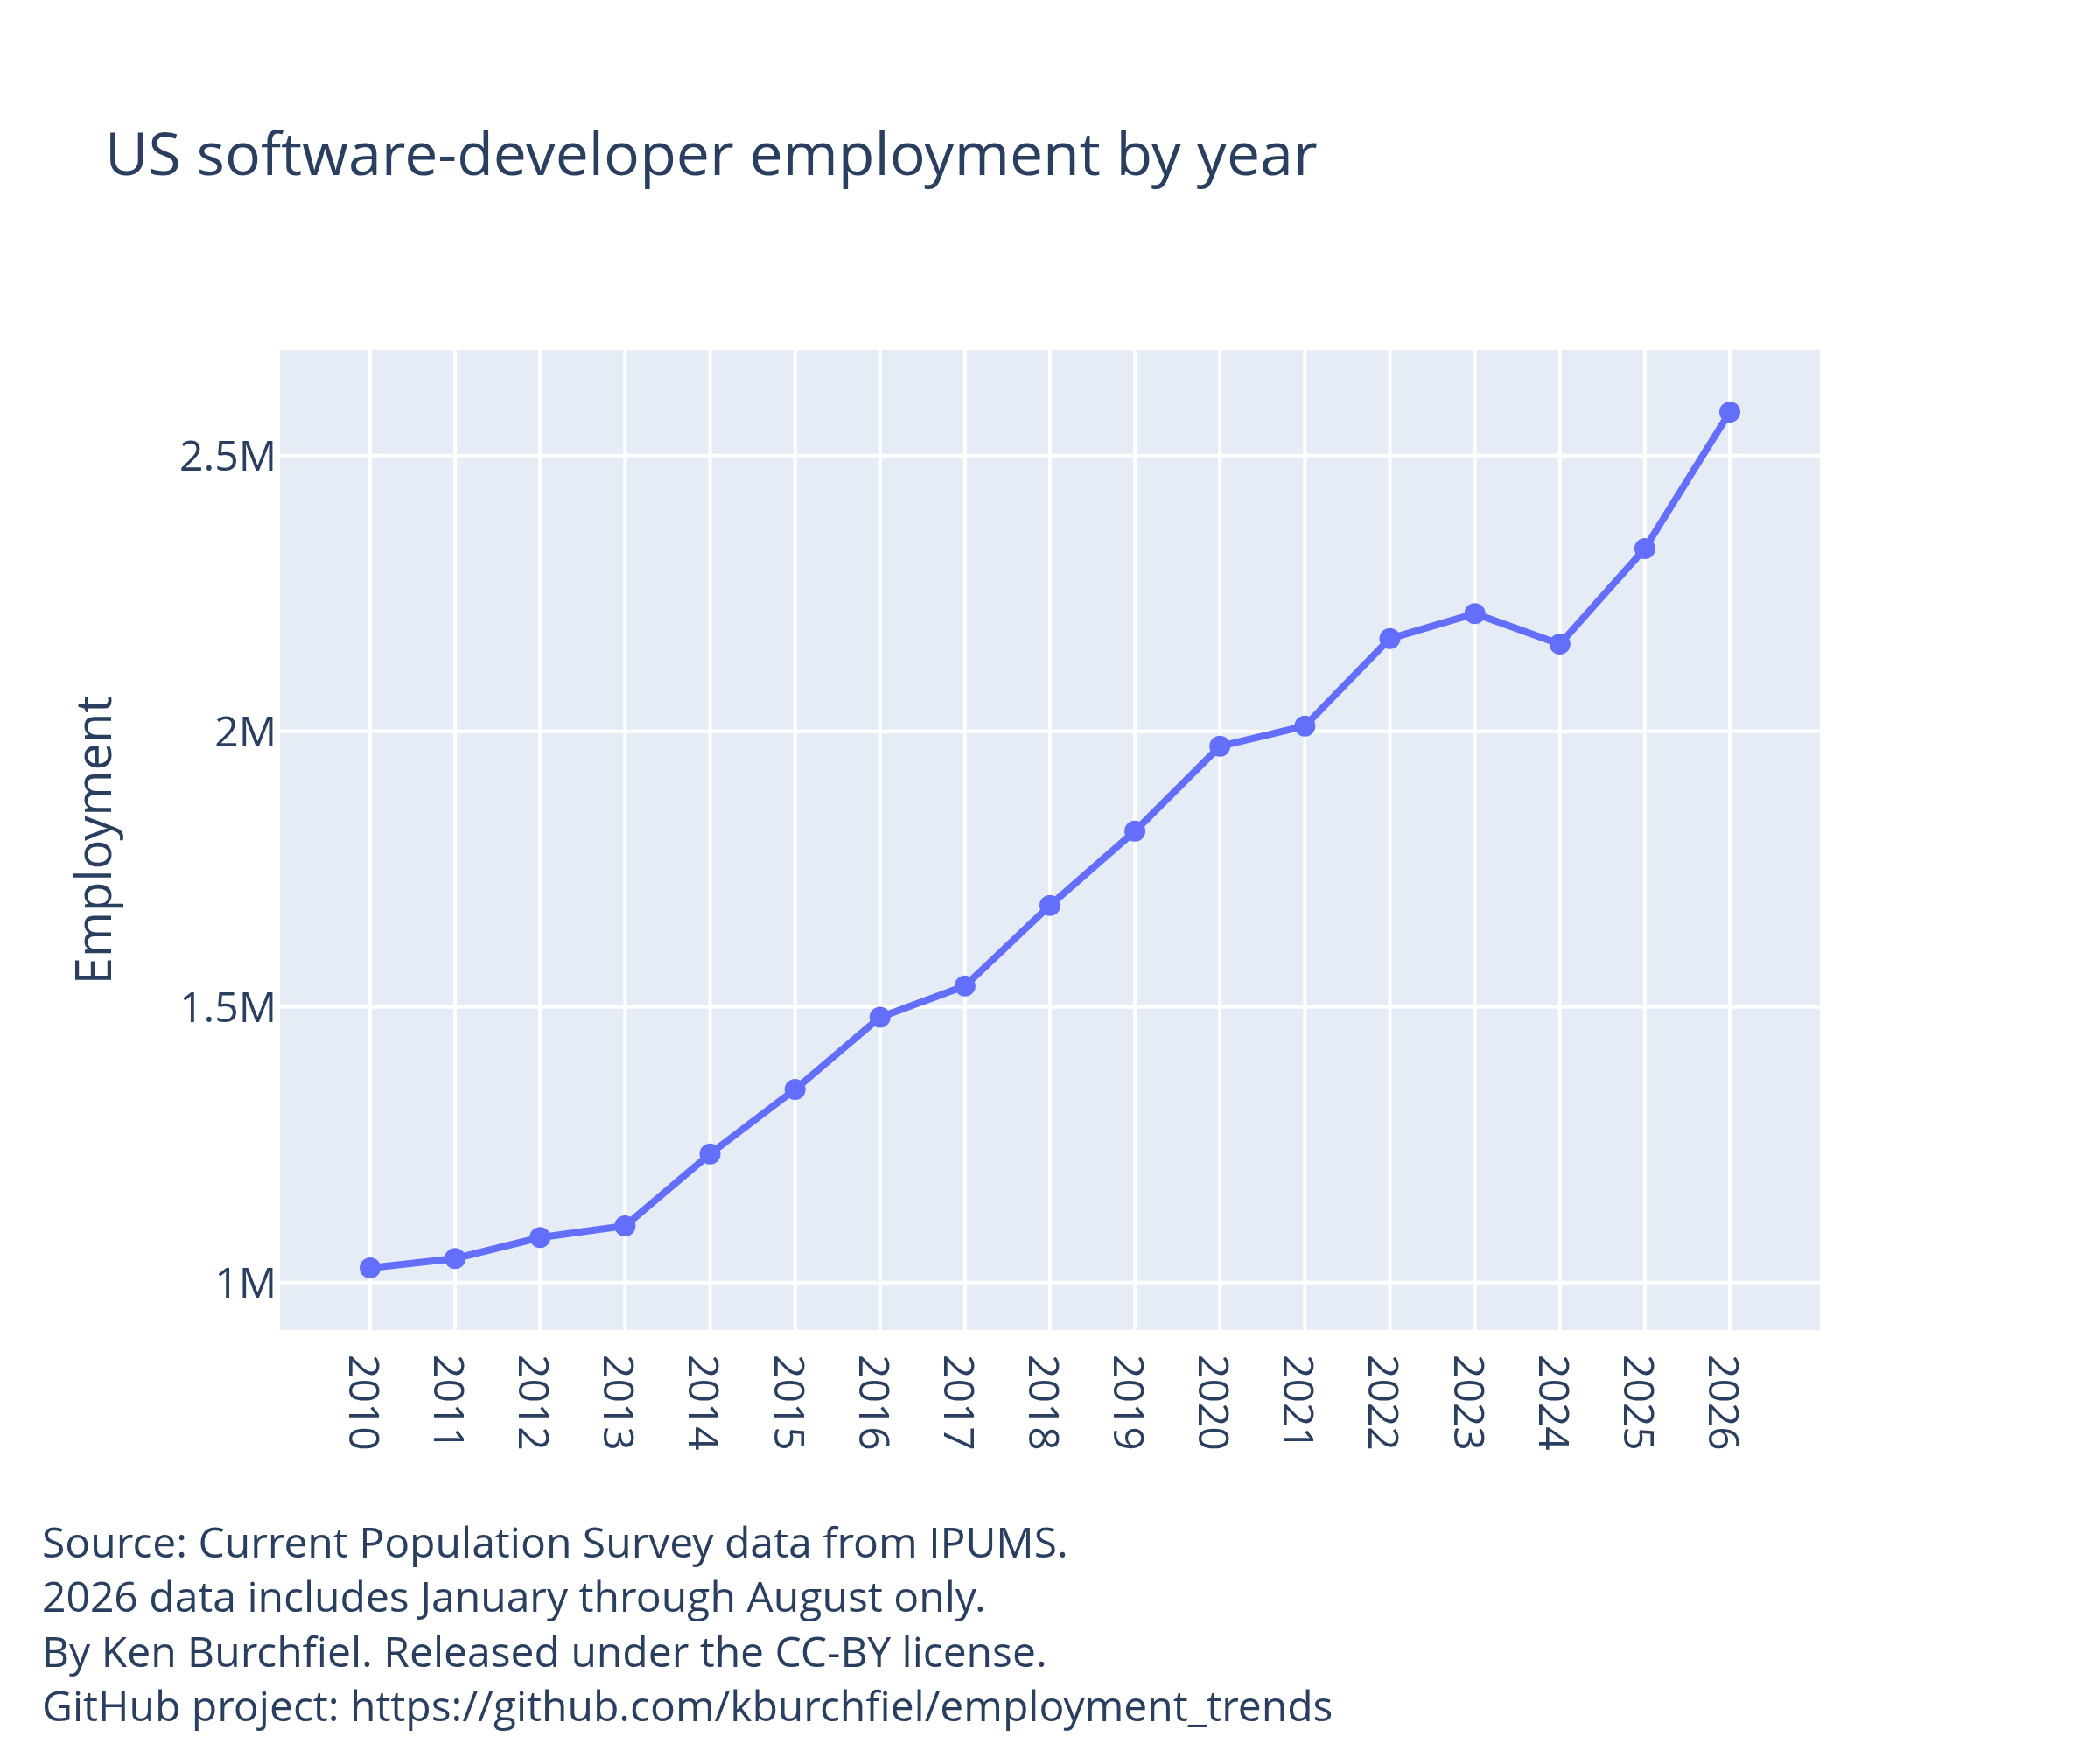

In [7]:
title = 'US software-developer employment by year'
margin_b = 120
margin_t = 100
default_file_path = 'Charts/software_developer_employment_by_year'

for error_y, error_y_minus in [['error_upper_emp_total', 
    'error_lower_emp_total'], [None, None]]:

    print("Error-bar variables:", error_y, error_y_minus)
    
    chart_subtitle = ''
    markers=True
    file_path = default_file_path
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        file_path = default_file_path+'_with_error_bars'
        chart_subtitle = error_bar_text
        markers=False        
        
    
    fig = px.line(df_full_emp_totals.query(
    "(period == 'year_as_str') & (age_range == 'All') & (occ2010 == 'Software \
developers, applications and systems software')").copy(),
    x = 'period_val', y = 'Total_emp_total', 
    hover_data = 'Response_Count_emp_total', markers=markers,
    height = chart_height,
    error_y = error_y, error_y_minus = error_y_minus).update_layout(
    xaxis_title = None, yaxis_title = 'Employment', 
    margin_b = margin_b, margin_t = margin_t)

    if len(chart_subtitle) > 0:
        title_and_subtitle = title + '<br><sub>' + chart_subtitle + '</sub>'
    else:
        title_and_subtitle = title

    # Creating an interactive chart in which titles and annotations can 
    # be wrapped as needed:
    
    # Plotly, to the best of my knowledge, doesn't allow titles and
    # annotations to be wrapped. In addition, it can be hard to ensure 
    # correct placement of annotations for responsive (i.e. non-static) 
    # charts.
    # Therefore, a workaround I learned online was to separate the chart 
    # title and subtitle into separate HTML elements. This both allows for 
    # text wrapping and simplifies the process of correctly positioning 
    # annotations.
    
    fig_for_HTML = go.Figure(fig) # Allows us to make a copy of the figure
    # that will be better suited for HTML display
    
    # Updating this figure for HTML rendering:
    # Since the title and annotation will be stored as separate HTML
    # elements, we can (and should) set margin_t and margin_b to 0
    # so that they'll be closer to the figure. We should also subtract
    # our original margin_t and margin_b values from the chart's height
    # in order to account for these removed items. (Otherwise, the chart
    # will be taller than necessary.)
    
    fig_for_HTML.update_layout(
    height = chart_height - margin_t - margin_b,
    margin_t = 0, margin_b = 0) # Setting the top and bottom margins
    # to 0 will allow our separate title and annotation elements to move
    # closer to the actual chart

    # Creating an HTML copy of this file:
    fig_as_html = fig_for_HTML.to_html(config={'responsive':True}, 
    full_html = False, include_plotlyjs='cdn')

    # Creating a string that combines the title, figure, and annotation
    # together, thus allowing them to be saved as a single HTML file:
    # (Alternatively, I could use my Jinja2 template to add the title
    # and annotation to my final page. That approach would make it easier to 
    # customize the styling of my title and annotation elements, but would 
    # also be more complex.)
    # Adding class names to the title and annotation elements will 
    # make them easier to style within our final HTML file.
    title_fig_and_annotation = f"<h2 class = 'chart_title'>{title}</h2><div>{fig_as_html}\
    </div><p class = 'chart_annotation'>{annotation_text}</p>"

    with open(file_path+'.html', 'w') as file:
        file.write(title_fig_and_annotation)

    # Preparing the figure for PNG export: (This will involve adding
    # in our title and subtitle.)
    fig.update_layout(title = title_and_subtitle)
    fig.add_annotation(x = -0.16, y = -0.42, align = 'left',
    text = annotation_text, showarrow = False,
    xref = 'paper', yref = 'paper')

    print(file_path)
    
    save_and_display_image(fig, file_path, 
    chart_height, chart_width, chart_scale)

### Creating similar charts at the monthly level:

In [ ]:
for error_y, error_y_minus in [['error_upper_emp_total', 
    'error_lower_emp_total'], [None, None]]:

    print("Error-bar variables:", error_y, error_y_minus)
    
    chart_subtitle = ''
    markers=True
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        chart_subtitle = '<i>Error bars represent 95% confidence intervals</i>'
        markers=False
    
    fig = px.line(df_full_emp_totals.query(
    "(period == 'year_and_month') & (age_range == 'All') & (occ2010 == 'Software \
developers, applications and systems software') & (period_val >= '2022-01')").copy(),
    x = 'period_val', y = 'Total_emp_total', 
    hover_data = 'Response_Count_emp_total',
    title = 'US software-developer employment by year and month',
    subtitle = chart_subtitle, markers=markers,
    height = chart_height, ,
    error_y = error_y, error_y_minus = error_y_minus).update_layout(
    xaxis_title = None, yaxis_title = 'Employment',
    margin_b = 120, 
    #    xaxis_type = 'category' # Allows year-month pairs to be labeled,
        # but adds unnecessary clutter to the chart
    )
    fig.add_annotation(x = -0.16, y = -0.42, align = 'left',
    text = annotation_text, showarrow = False,
    xref = 'paper', yref = 'paper')
    
    file_path = 'Charts/software_developer_employment_by_year_and_month'
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        file_path = file_path + '_with_error_bars'

    print(file_path)
    
    save_and_display_image(fig, file_path, chart_height, chart_width, chart_scale)

Graphing software-developer employment by year and age range:

In [ ]:
fig = px.line(df_full_emp_totals.query(
"(period == 'year_as_str') & (age_range != 'All') & (occ2010 == 'Software \
developers, applications and systems software')"),
x = 'period_val', y = 'Total_emp_total', 
hover_data = 'Response_Count_emp_total', 
color = 'age_range')
# Ensuring that the years will be in chronological order, even if data for
# certain age ranges isn't present for all years:
# Any individual age-range value could have been used here instead of 'All';
# what's important is to show just one set of period entries so that we don't have
# duplicate entries within our sort criteria.
fig.update_xaxes(categoryorder = 'array', 
categoryarray = df_full_emp_totals.query(
"period == 'year_as_str' & age_range == 'All'").sort_values(
'period_val')['period_val'].unique())

Creating a simplified static copy of this chart:

In [ ]:
for error_y, error_y_minus in [['error_upper_emp_total', 
    'error_lower_emp_total'], [None, None]]:

    print("Error-bar variables:", error_y, error_y_minus)
    
    chart_subtitle = ''
    markers=True
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        chart_subtitle = '<i>Error bars represent 95% confidence intervals</i>'
        markers=False
    
    fig = px.line(df_full_emp_totals.query(
    "(period == 'year_as_str') & (age_range != 'All') & (occ2010 == 'Software \
developers, applications and systems software') & (period_val >= '2022')"),
    x = 'period_val', y = 'Total_emp_total', 
    hover_data = 'Response_Count_emp_total',
    color = 'age_range',
    title = 'US software-developer employment by year and age range',
    subtitle = chart_subtitle, markers=markers,
    height = chart_height, ,
    error_y = error_y, error_y_minus = error_y_minus).update_layout(
    xaxis_title = None, yaxis_title = 'Employment',
    margin_b = 120
    #    xaxis_type = 'category' # Allows year-month pairs to be labeled,
        # but adds unnecessary clutter to the chart
    ).update_layout(xaxis_title = None, 
yaxis_title = 'Employment', legend_title = 'Age range')
    fig.add_annotation(x = -0.16, y = -0.42, align = 'left',
    text = annotation_text, showarrow = False,
    xref = 'paper', yref = 'paper')
    
    file_path = 'Charts/software_developer_employment_by_year_and_age_range'
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        file_path = file_path + '_with_error_bars'

    print(file_path)
    
    save_and_display_image(fig, file_path, chart_height, chart_width, chart_scale)

In [ ]:
fig = px.line(df_full_emp_totals.query(
"(period == 'year_as_str') & (age_range != 'All') & (occ2010 == 'Software \
developers, applications and systems software') & (period_val >= '2022')"),
x = 'period_val', y = 'Total_emp_total', 
hover_data = 'Response_Count_emp_total',
color = 'age_range',
error_y = 'error_upper_emp_total',
error_y_minus = 'error_lower_emp_total',
height = chart_height, ,
title = 'US software-developer employment by year and age range',
subtitle = error_bar_text).update_layout(xaxis_title = None, 
yaxis_title = 'Employment', legend_title = 'Age range')

fig


The monthly data for employment totals for specific age ranges is much 'noisier':

In [ ]:
fig = px.line(df_full_emp_totals.query(
"(period == 'year_and_month') & (age_range != 'All') & (occ2010 == 'Software \
developers, applications and systems software')"),
x = 'period_val', y = 'Total_emp_total', 
hover_data = 'Response_Count_emp_total', 
color = 'age_range')
fig.update_xaxes(categoryorder = 'array',
categoryarray = df_full_emp_totals.query(
"period == 'year_and_month' & age_range == 'All'").sort_values(
'period_val')['period_val'].unique())

## Running regressions to see whether software-developer employment has increased significantly since 2022:

In [ ]:
# reg_sample = svy.Sample(data = pl.DataFrame(df.query("year_and_month >= '2022-10'").sample(
# frac=0.001, random_state = 0)[['wtfinl', 'employed', 'occ2010', 'Count', "year_and_month", 'final_stratum_revision', 'cpsid']]), design = reg_sample_design)

It looks like a 22-65 age filter will capture nearly all software developers:

In [ ]:
100*len(df.query("age_as_int >= 22 & age_as_int <= 65 \
& employed_as_software_developer == 1")) / len(df.query("employed_as_software_developer == 1"))

Creating a subset of our data that can be used for proportion and regression analyses:

(We could also consider limiting the following analysis to individuals who are in the labor force, but this would then exclude discouraged developers (and others) who chose to exit the labor force due to trouble finding a job.)m

In [ ]:
data_for_sample = pl.DataFrame(
df.query("year_and_month >= '2022-10'")[['wtfinl', 'year_and_half_wtfinl', 
'year_and_quarter_wtfinl', 'year_wtfinl', 'employed', 'employed_as_software_developer',
'occ2010', 'Count', "year_as_str", "year_and_half", "year_and_quarter",
"year_and_month", 'age_as_int', 'final_stratum_revision', 
'cpsid', 'age_range']])

Creating survey samples for analysis: 

In [ ]:
year_and_month_logistic_reg_sample = svy.Sample(
data_for_sample, design = svy.Design(stratum = "final_stratum_revision",
                               psu = 'cpsid', wgt = 'wtfinl'))

year_and_half_logistic_reg_sample = svy.Sample(
data_for_sample, design = svy.Design(stratum = "final_stratum_revision",
                               psu = 'cpsid', wgt = 'year_and_half_wtfinl'))

year_and_quarter_logistic_reg_sample = svy.Sample(
data_for_sample, design = svy.Design(stratum = "final_stratum_revision",
                               psu = 'cpsid', wgt = 'year_and_quarter_wtfinl'))

year_logistic_reg_sample = svy.Sample(
data_for_sample, design = svy.Design(stratum = "final_stratum_revision",
                               psu = 'cpsid', wgt = 'year_wtfinl'))


In [ ]:
## Checking values

## Evaluating trends in the *proportion* of Americans ages 22-65 who have been employed as software developers:

Specifying an age range for our proportion analyses:

In [ ]:
proportion_where_arg = [svy.col("age_as_int") >= 22, svy.col("age_as_int") <= 65]

In [ ]:
reference_period = 'year_and_month'
swe_employment_year_month_props = perform_svy_analysis(
sample = year_and_month_logistic_reg_sample, 
y = "employed_as_software_developer", analysis_type = 'prop', by = [
reference_period], where = proportion_where_arg, col_suffix = '', count_col = 'Count')

swe_employment_year_month_props

Visualizing these changes in proportions:

In [ ]:
chart_width = 600
chart_height = 500

for error_y, error_y_minus in [['error_upper_as_pct', 
    'error_lower_as_pct'], [None, None]]:

    print("Error-bar variables:", error_y, error_y_minus)
    
    chart_subtitle = ''
    markers=True
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        chart_subtitle = error_bar_text
        markers=False
    
    fig = px.line(swe_employment_year_month_props.query(
    "employed_as_software_developer == '1'"), x = reference_period,
    y = 'est_as_pct', error_y = error_y, error_y_minus = error_y_minus,
    markers=markers,
    title = '% of Americans aged 22-65, by year and month,<br>who are employed as \
software developers', subtitle = chart_subtitle, height = chart_height, 
    ).update_layout(
    xaxis_title = None, yaxis_title = '% employed', margin_b = 120,
    title_y = 0.94)
    
    fig.add_annotation(x = -0.16, y = -0.42, align = 'left',
    text = annotation_text, showarrow = False,
    xref = 'paper', yref = 'paper')
    
    file_path = 'Charts/developer_employment_proportion_by_year_and_month'
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        file_path = file_path + '_with_error_bars'

    print(file_path)
    
    save_and_display_image(fig, file_path, chart_height, chart_width, chart_scale)

In [ ]:
chart_height = 500
chart_width = 800
fig = px.line(swe_employment_year_month_props.query(
"employed_as_software_developer == '1'"), x = reference_period, 
y = 'est_as_pct', error_y = 'error_upper_as_pct', error_y_minus = 'error_lower_as_pct',
title = 'Changes in the % of Americans (in the CPS sample) aged 22-65<br>\
who are employed as software developers', height = chart_height, )
fig

### Using a logistic regression to see whether the *proportion* of the US population ages 22-65 who are employed as software developers has increased significantly from certain months to the most recent month in the dataset:

In [ ]:
df_year_month_reg_results = create_svy_reg(
    sample = year_and_month_logistic_reg_sample,
y = "employed_as_software_developer", x_list = [svy.Cat(reference_period, 
ref = df[reference_period].max())], regression_type="logistic", 
where = proportion_where_arg)

df_year_month_reg_results

### Performing similar proportion calculations and regression analyses at the quarterly, biannual, and yearly level:

### By quarter:

In [ ]:
reference_period = "year_and_quarter"
df_year_and_quarter_reg_results = create_svy_reg(
    sample = year_and_quarter_logistic_reg_sample,
y = "employed_as_software_developer", x_list = [svy.Cat(reference_period, 
ref = df[reference_period].max())], regression_type="logistic", 
where = proportion_where_arg)

df_year_and_quarter_reg_results

Calculating and visualizing proportions:

In [ ]:
swe_employment_year_and_quarter_props = perform_svy_analysis(
sample = year_and_quarter_logistic_reg_sample, 
y = "employed_as_software_developer", analysis_type = 'prop', by = [
reference_period], where = proportion_where_arg, col_suffix = '', count_col = 'Count')

swe_employment_year_and_quarter_props

In [ ]:
chart_height = 500
chart_width = 800
fig = px.line(swe_employment_year_and_quarter_props.query(
"employed_as_software_developer == '1'"), x = reference_period,
y = 'est_as_pct', error_y = 'error_upper_as_pct', error_y_minus = 'error_lower_as_pct',
title = 'Changes in the % of Americans (in the CPS sample) aged 22-65<br>\
who are employed as software developers', height = chart_height, )
fig

### By half:

In [ ]:
reference_period = "year_and_half"
df_year_and_half_reg_results = create_svy_reg(
    sample = year_and_half_logistic_reg_sample,
y = "employed_as_software_developer", x_list = [svy.Cat(reference_period, 
ref = df[reference_period].max())], regression_type="logistic", 
where = proportion_where_arg)

df_year_and_half_reg_results

In [ ]:
swe_employment_year_and_half_props = perform_svy_analysis(
sample = year_and_half_logistic_reg_sample, 
y = "employed_as_software_developer", analysis_type = 'prop', by = [
reference_period], where = proportion_where_arg, col_suffix = '', count_col = 'Count')

swe_employment_year_and_half_props

In [ ]:
chart_height = 500
chart_width = 800
fig = px.line(swe_employment_year_and_half_props.query(
"employed_as_software_developer == '1'"), x = reference_period,
y = 'est_as_pct', error_y = 'error_upper_as_pct', error_y_minus = 'error_lower_as_pct',
title = 'Changes in the % of Americans (in the CPS sample) aged 22-65<br>\
who are employed as software developers', height = chart_height, )
fig

## By year:

In [ ]:
reference_period = "year_as_str"
df_year_reg_results = create_svy_reg(
    sample = year_logistic_reg_sample,
y = "employed_as_software_developer", x_list = [svy.Cat(reference_period, 
ref = df[reference_period].max())], regression_type="logistic", 
where = proportion_where_arg)

df_year_reg_results

In [ ]:
swe_employment_year_props = perform_svy_analysis(
sample = year_logistic_reg_sample, 
y = "employed_as_software_developer", analysis_type = 'prop', by = [
reference_period], where = proportion_where_arg, col_suffix = '', count_col = 'Count')

swe_employment_year_props

In [ ]:
chart_width = 600
chart_height = 500

for error_y, error_y_minus in [['error_upper_as_pct', 
    'error_lower_as_pct'], [None, None]]:

    print("Error-bar variables:", error_y, error_y_minus)
    
    chart_subtitle = ''
    markers=True
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        chart_subtitle = error_bar_text
        markers=False
    
    fig = px.line(swe_employment_year_props.query(
    "employed_as_software_developer == '1'"), x = reference_period,
    y = 'est_as_pct', error_y = error_y, error_y_minus = error_y_minus,
    markers=markers,
    title = '% of Americans aged 22-65 who are employed as \
software developers', subtitle = chart_subtitle, height = chart_height, 
    ).update_layout(
    xaxis_title = None, yaxis_title = '% employed', margin_b = 120,
    title_y = 0.94)
    
    fig.add_annotation(x = -0.16, y = -0.42, align = 'left',
    text = annotation_text, showarrow = False,
    xref = 'paper', yref = 'paper')
    
    file_path = 'Charts/developer_employment_proportion_by_year'
    if error_y is not None:
        # Adding a suffix to distinguish this chart from the error-bar-free
        # one
        file_path = file_path + '_with_error_bars'

    print(file_path)
    
    save_and_display_image(fig, file_path, chart_height, chart_width, chart_scale)

## Evaluating proportions by year and age range:

(ACS data, given its much larger sample size, may be a better fit for this type of analysis, though the CPS offers more recent data.)

In [ ]:
swe_employment_year_props_by_age_range = perform_svy_analysis(
sample = year_logistic_reg_sample, 
y = "employed_as_software_developer", analysis_type = 'prop', by = [
reference_period, 'age_range'],
where = proportion_where_arg, col_suffix = '', count_col = 'Count')

swe_employment_year_props_by_age_range

In [ ]:
chart_height = 500
chart_width = 800
fig = px.line(swe_employment_year_props_by_age_range.query(
"employed_as_software_developer == '1'"), x = reference_period,
y = 'est_as_pct', color = 'age_range', error_y = 'error_upper_as_pct', 
error_y_minus = 'error_lower_as_pct',
title = 'Changes in the % of Americans (in the CPS sample) aged 22-65<br>\
who are employed as software developers', height = chart_height, )
fig

## Checking unemployment data:

**Note:** Due to low sample sizes, the ACS may be a better source of occupation-specific unemployment estimates than the CPS (though its data isn't as recent).

Graphing yearly %-unemployed estimates:

In [ ]:
px.line(df_ue_props.query(
"period == 'year_as_str' & occ2010 == 'Software developers, \
applications and systems software' & empstat_condensed_ue_prop == \
'Unemployed' & age_range == 'All'"), x = 'period_val', 
y = 'est_ue_prop',
error_y = 'error_upper_ue_prop', error_y_minus = 'error_lower_ue_prop',
title = 'Estimated proportion of software developers who are unemployed')

## Graphing these estimates by age range:

(I wouldn't place much confidence at all in these results, given the low sample sizes we're working with. I filtered out the under-22 group because it had particularly low counts.)

In [ ]:
px.line(df_ue_props.query(
"period == 'year_as_str' & occ2010 == 'Software developers, \
applications and systems software' & empstat_condensed_ue_prop == \
'Unemployed' & age_range not in ['All', 'Under 22']"), x = 'period_val', 
y = 'est_ue_prop', color = 'age_range',
error_y = 'error_upper_ue_prop', error_y_minus = 'error_lower_ue_prop',
title = 'Estimated proportion of software developers, by age range, who are unemployed')

The monthly data is too 'noisy' to be useful:

In [ ]:
px.line(df_ue_props.query(
"period == 'year_and_month' & occ2010 == 'Software developers, \
applications and systems software' & empstat_condensed_ue_prop == \
'Unemployed' & age_range == 'All'"), x = 'period_val', 
y = 'est_ue_prop',
error_y = 'error_upper_ue_prop', error_y_minus = 'error_lower_ue_prop',
title = 'Estimated proportion of software developers who are unemployed')

The quarterly data is a bit more manageable:

In [ ]:
px.line(df_ue_props.query(
"period == 'year_and_quarter' & occ2010 == 'Software developers, \
applications and systems software' & empstat_condensed_ue_prop == \
'Unemployed' & age_range == 'All'"), x = 'period_val', 
y = 'est_ue_prop',
error_y = 'error_upper_ue_prop', error_y_minus = 'error_lower_ue_prop',
title = 'Estimated proportion of software developers who are unemployed')

## To do: Add in logistic regressions that test for significant changes in unemployment by period.

In [ ]:
end_time = time.time()
print(f"{datetime.now().isoformat(sep = ' ', 
timespec = 'seconds')}: The script finished running in {
round(end_time - start_time, 3)} seconds.")